# Notebook 02 — Wrapper POMDP & PPO-MLP sur CartPole-MaskedVelocity

**Objectif :**
1. Démontrer le wrapper `MaskVelocityWrapper` (notre apport personnel)
2. Lancer PPO-MLP sur la variante POMDP — **attendu : dégradation forte** (l'agent ne peut pas inférer les vitesses sans mémoire)

Ce notebook **motive** l'introduction d'un LSTM dans le NB 03.

## Setup

In [19]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

ROOT = c:\Users\Pape Malick\works\ppo-recurrent-pomdp


## 1. Démo du wrapper MaskVelocityWrapper

CartPole-v1 a 4 dimensions d'observation : `[x, x_dot, theta, theta_dot]`.

Notre wrapper supprime les indices 1 et 3 (les vitesses) → l'agent ne reçoit que `[x, theta]`.
Pour décider de l'action optimale, il doit **inférer** les vitesses à partir de l'historique.

In [20]:
import gymnasium as gym
import numpy as np
from src.envs.pomdp_wrappers import MaskVelocityWrapper

# Comparaison MDP vs POMDP
env_full = gym.make("CartPole-v1")
env_pomdp = MaskVelocityWrapper(gym.make("CartPole-v1"))

print(f"MDP   observation_space : {env_full.observation_space}")
print(f"POMDP observation_space : {env_pomdp.observation_space}")
print()

obs_full, _ = env_full.reset(seed=42)
obs_pomdp, _ = env_pomdp.reset(seed=42)
print(f"MDP   obs : {obs_full}   (x, x_dot, theta, theta_dot)")
print(f"POMDP obs : {obs_pomdp}   (x, theta uniquement)")
print()
print("✅ Les positions correspondent, les vitesses sont supprimées.")

MDP   observation_space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
POMDP observation_space : Box([-4.8        -0.41887903], [4.8        0.41887903], (2,), float32)

MDP   obs : [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]   (x, x_dot, theta, theta_dot)
POMDP obs : [0.0273956  0.03585979]   (x, theta uniquement)

✅ Les positions correspondent, les vitesses sont supprimées.


## 2. Entraînement PPO-MLP sur CartPole-MaskedVelocity

On utilise **exactement la même implémentation PPO-MLP** que NB 01 — seul l'env change.
Cela isole l'effet de l'observabilité partielle.

In [21]:
import os, random, time, json
from dataclasses import dataclass, asdict
from pathlib import Path

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical
import matplotlib.pyplot as plt


@dataclass
class Args:
    exp_name: str = "ppo_mlp"
    seed: int = 1
    cuda: bool = True
    env_id: str = "CartPole-v1"
    total_timesteps: int = 100_000
    learning_rate: float = 2.5e-4
    anneal_lr: bool = True
    num_envs: int = 4
    num_steps: int = 128
    gamma: float = 0.99
    gae_lambda: float = 0.95
    num_minibatches: int = 4
    update_epochs: int = 4
    norm_adv: bool = True
    clip_coef: float = 0.2
    clip_vloss: bool = True
    ent_coef: float = 0.01
    vf_coef: float = 0.5
    max_grad_norm: float = 0.5
    use_masked_velocity: bool = False  # passe à True pour le POMDP

    @property
    def batch_size(self): return self.num_envs * self.num_steps
    @property
    def minibatch_size(self): return self.batch_size // self.num_minibatches
    @property
    def num_iterations(self): return self.total_timesteps // self.batch_size


def set_global_seed(seed, det=True):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = det; torch.backends.cudnn.benchmark = not det
    os.environ.setdefault("PYTHONHASHSEED", str(seed))


def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class AgentMLP(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=64):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, 1), std=1.0),
        )
        self.actor = nn.Sequential(
            layer_init(nn.Linear(obs_dim, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, hidden_size)), nn.Tanh(),
            layer_init(nn.Linear(hidden_size, n_actions), std=0.01),
        )
    def get_value(self, x): return self.critic(x)
    def get_action_and_value(self, x, action=None):
        logits = self.actor(x)
        dist = Categorical(logits=logits)
        if action is None: action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(x)


def make_env(env_id, seed, idx, use_masked_velocity=False):
    def thunk():
        env = gym.make(env_id)
        if use_masked_velocity:
            from src.envs.pomdp_wrappers import MaskVelocityWrapper
            env = MaskVelocityWrapper(env)
        env = gym.wrappers.RecordEpisodeStatistics(env)
        env.action_space.seed(seed + idx)
        return env
    return thunk


def train_ppo_mlp(args, run_name):
    set_global_seed(args.seed)
    device = torch.device("cuda" if args.cuda and torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    envs = gym.vector.SyncVectorEnv([
        make_env(args.env_id, args.seed, i, args.use_masked_velocity)
        for i in range(args.num_envs)
    ])
    obs_shape = envs.single_observation_space.shape
    n_actions = envs.single_action_space.n
    obs_dim = int(np.prod(obs_shape))
    print(f"obs_shape={obs_shape}, n_actions={n_actions}")

    agent = AgentMLP(obs_dim, n_actions).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=args.learning_rate, eps=1e-5)

    obs_buf = torch.zeros((args.num_steps, args.num_envs) + obs_shape, device=device)
    actions_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    logprobs_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    rewards_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    dones_buf = torch.zeros((args.num_steps, args.num_envs), device=device)
    values_buf = torch.zeros((args.num_steps, args.num_envs), device=device)

    history = {"step": [], "episodic_return": []}
    global_step = 0
    start = time.time()
    next_obs, _ = envs.reset(seed=args.seed)
    next_obs = torch.tensor(next_obs, dtype=torch.float32, device=device)
    next_done = torch.zeros(args.num_envs, device=device)

    for iteration in range(1, args.num_iterations + 1):
        if args.anneal_lr:
            frac = 1.0 - (iteration - 1) / args.num_iterations
            for pg in optimizer.param_groups: pg["lr"] = frac * args.learning_rate

        for step in range(args.num_steps):
            global_step += args.num_envs
            obs_buf[step] = next_obs
            dones_buf[step] = next_done
            with torch.no_grad():
                action, logprob, _, value = agent.get_action_and_value(next_obs)
                values_buf[step] = value.flatten()
            actions_buf[step] = action
            logprobs_buf[step] = logprob
            obs_np, reward, term, trunc, info = envs.step(action.cpu().numpy())
            rewards_buf[step] = torch.tensor(reward, dtype=torch.float32, device=device)
            done_np = np.logical_or(term, trunc)
            next_obs = torch.tensor(obs_np, dtype=torch.float32, device=device)
            next_done = torch.tensor(done_np, dtype=torch.float32, device=device)
            # Logging compatible Gymnasium 0.29 et 1.x
            if "final_info" in info:
                for env_info in info["final_info"]:
                    if env_info and "episode" in env_info:
                        history["step"].append(global_step)
                        history["episodic_return"].append(float(env_info["episode"]["r"]))
            elif "episode" in info and "_episode" in info:
                mask = info["_episode"]
                if np.any(mask):
                    for idx in np.where(mask)[0]:
                        history["step"].append(global_step)
                        history["episodic_return"].append(float(info["episode"]["r"][idx]))

        with torch.no_grad():
            next_value = agent.get_value(next_obs).reshape(1, -1)
            advantages = torch.zeros_like(rewards_buf)
            lastgaelam = 0.0
            for t in reversed(range(args.num_steps)):
                if t == args.num_steps - 1:
                    nextnonterm = 1.0 - next_done; nextvals = next_value
                else:
                    nextnonterm = 1.0 - dones_buf[t+1]; nextvals = values_buf[t+1]
                delta = rewards_buf[t] + args.gamma * nextvals * nextnonterm - values_buf[t]
                advantages[t] = lastgaelam = delta + args.gamma * args.gae_lambda * nextnonterm * lastgaelam
            returns = advantages + values_buf

        b_obs = obs_buf.reshape((-1,) + obs_shape)
        b_logprobs = logprobs_buf.reshape(-1)
        b_actions = actions_buf.reshape(-1).long()
        b_advantages = advantages.reshape(-1)
        b_returns = returns.reshape(-1)
        b_values = values_buf.reshape(-1)
        b_inds = np.arange(args.batch_size)

        for epoch in range(args.update_epochs):
            np.random.shuffle(b_inds)
            for s in range(0, args.batch_size, args.minibatch_size):
                mb = b_inds[s:s+args.minibatch_size]
                _, newlogprob, entropy, newvalue = agent.get_action_and_value(b_obs[mb], b_actions[mb])
                logratio = newlogprob - b_logprobs[mb]
                ratio = logratio.exp()
                mb_adv = b_advantages[mb]
                if args.norm_adv:
                    mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)
                pg_loss1 = -mb_adv * ratio
                pg_loss2 = -mb_adv * torch.clamp(ratio, 1-args.clip_coef, 1+args.clip_coef)
                pg_loss = torch.max(pg_loss1, pg_loss2).mean()
                newvalue = newvalue.view(-1)
                if args.clip_vloss:
                    v_clipped = b_values[mb] + torch.clamp(newvalue - b_values[mb], -args.clip_coef, args.clip_coef)
                    v_loss = 0.5 * torch.max((newvalue - b_returns[mb])**2, (v_clipped - b_returns[mb])**2).mean()
                else:
                    v_loss = 0.5 * ((newvalue - b_returns[mb])**2).mean()
                ent_loss = entropy.mean()
                loss = pg_loss - args.ent_coef * ent_loss + args.vf_coef * v_loss
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(agent.parameters(), args.max_grad_norm)
                optimizer.step()

        if iteration % 20 == 0 or iteration == 1:
            recent = history["episodic_return"][-20:] if history["episodic_return"] else [0]
            sps = int(global_step / (time.time() - start))
            print(f"iter {iteration:4d} | step {global_step:7d} | return(20)={np.mean(recent):6.1f} | SPS={sps}")

    envs.close()
    print(f"\nDurée totale : {time.time()-start:.1f}s")
    return agent, history


In [22]:
args = Args(
    exp_name="ppo_mlp_cartpole_masked",
    env_id="CartPole-v1",
    use_masked_velocity=True,   # ← seule différence avec NB 01
    total_timesteps=300_000,    # un peu plus, POMDP est plus dur
    seed=1,
)
run_name = f"{args.exp_name}__seed{args.seed}"
agent, history = train_ppo_mlp(args, run_name)

Device: cpu
obs_shape=(2,), n_actions=2
iter    1 | step     512 | return(20)=  19.6 | SPS=1465
iter   20 | step   10240 | return(20)=  26.5 | SPS=2967
iter   40 | step   20480 | return(20)=  35.4 | SPS=3291
iter   60 | step   30720 | return(20)=  36.1 | SPS=3417
iter   80 | step   40960 | return(20)=  40.9 | SPS=3485
iter  100 | step   51200 | return(20)=  38.5 | SPS=3511
iter  120 | step   61440 | return(20)=  47.7 | SPS=3556
iter  140 | step   71680 | return(20)=  55.2 | SPS=3562
iter  160 | step   81920 | return(20)=  46.8 | SPS=3578
iter  180 | step   92160 | return(20)=  47.1 | SPS=3600
iter  200 | step  102400 | return(20)=  57.9 | SPS=3618
iter  220 | step  112640 | return(20)=  49.8 | SPS=3627
iter  240 | step  122880 | return(20)=  49.8 | SPS=3635
iter  260 | step  133120 | return(20)=  41.4 | SPS=3642
iter  280 | step  143360 | return(20)=  56.3 | SPS=3646
iter  300 | step  153600 | return(20)=  53.0 | SPS=3646
iter  320 | step  163840 | return(20)=  58.4 | SPS=3652
iter  34

## Courbe d'apprentissage — observe la dégradation

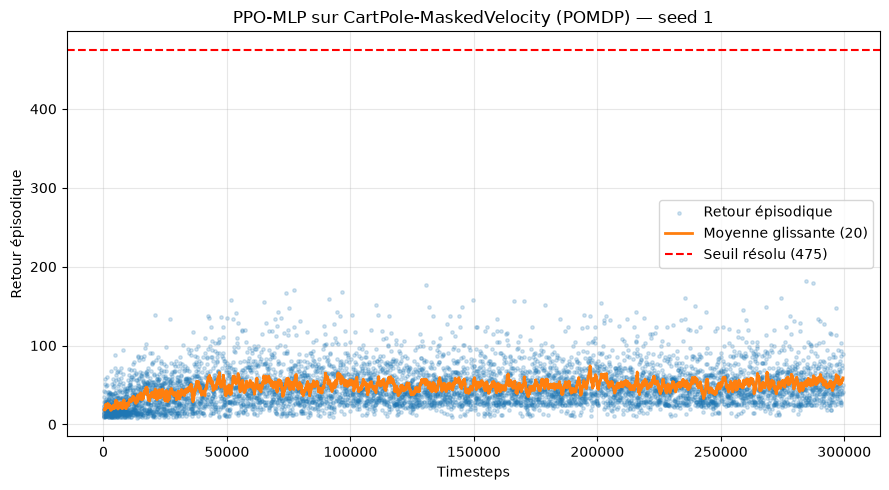

Figure → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_mlp_cartpole_masked__seed1.png

Retour moyen sur les 50 derniers épisodes : 54.04
Attendu : significativement < 475 (l'agent ne peut pas inférer les vitesses sans mémoire)


In [23]:
import matplotlib.pyplot as plt
import torch
import pandas as pd

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
steps = np.array(history["step"])
returns = np.array(history["episodic_return"])
ax.scatter(steps, returns, s=6, alpha=0.2, label="Retour épisodique")
if len(returns) >= 20:
    smooth = np.convolve(returns, np.ones(20)/20, mode="valid")
    ax.plot(steps[19:], smooth, color="C1", linewidth=2, label="Moyenne glissante (20)")
ax.axhline(475, color="red", linestyle="--", label="Seuil résolu (475)")
ax.set_xlabel("Timesteps")
ax.set_ylabel("Retour épisodique")
ax.set_title(f"PPO-MLP sur CartPole-MaskedVelocity (POMDP) — seed {args.seed}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = ROOT / "results" / "csv" / f"{run_name}.png"
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"Figure → {fig_path}")
print(f"\nRetour moyen sur les 50 derniers épisodes : {np.mean(returns[-50:]):.2f}")
print("Attendu : significativement < 475 (l'agent ne peut pas inférer les vitesses sans mémoire)")

## Sauvegarde

In [24]:
df = pd.DataFrame({"step": history["step"], "return": history["episodic_return"]})
df["config"] = "PPO-MLP / CartPole-Masked (POMDP)"
csv_path = ROOT / "results" / "csv" / f"{run_name}.csv"
df.to_csv(csv_path, index=False)
print(f"CSV → {csv_path}")

model_path = ROOT / "results" / "models" / f"{run_name}.pt"
torch.save(agent.state_dict(), model_path)
print(f"Modèle → {model_path}")

CSV → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\csv\ppo_mlp_cartpole_masked__seed1.csv
Modèle → c:\Users\Pape Malick\works\ppo-recurrent-pomdp\results\models\ppo_mlp_cartpole_masked__seed1.pt


## Conclusion intermédiaire

✅ Le wrapper fonctionne et fournit bien un POMDP.
⚠️ PPO-MLP **ne peut pas** atteindre la performance optimale sans accès aux vitesses : il manque d'information temporelle.

**Suite (NB 03) :** introduire un LSTM pour donner une mémoire à l'agent.